setup and transformers

In [5]:
import os
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from tqdm import tqdm

# --- CONFIGURATION ---
NUM_CLASSES = 64
NUM_FRAMES = 8
BATCH_SIZE = 16 
LR = 2e-5 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# Update this path to your Kaggle dataset location
DATA_ROOT = "/kaggle/input/lsa64-frames/LSA64_Frames" 

# --- DINOv2 SPECIFIC AUGMENTATION ---
# DINOv2 was trained on ImageNet standards. We use those exact means/stds.
train_transform = T.Compose([
    T.Resize((224, 224)),
    # Augmentations to prevent overfitting on specific subjects
    T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    # Critical: DINOv2 normalization values
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(f"✅ Cell 1 Complete. Using Device: {DEVICE}")

✅ Cell 1 Complete. Using Device: cuda


dataset

In [6]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image

class LSA64Dataset(Dataset):
    def __init__(self, root, transform=None, num_frames=8):
        self.samples = []
        self.root = root
        self.transform = transform
        self.num_frames = num_frames
        
        # Sahi folders (001, 002...) dhoondna
        class_folders = sorted([d for d in os.listdir(root) if d.isdigit()])
        
        for label_str in class_folders:
            class_path = os.path.join(root, label_str)
            for video_folder in os.listdir(class_path):
                video_path = os.path.join(class_path, video_folder)
                if os.path.isdir(video_path) and "_" in video_folder:
                    # Logic: folder name 001_002_003 -> Class_Subject_Repeat
                    parts = video_folder.split('_')
                    subject_id = int(parts[1]) 
                    self.samples.append({
                        'path': video_path,
                        'label': int(label_str) - 1,
                        'subject': subject_id
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        video_dir = sample['path']
        
        # Frames load karna
        all_frames = sorted([f for f in os.listdir(video_dir) if f.lower().endswith(('.png', '.jpg'))])
        
        # 8 frames uniformly pick karna
        idxs = np.linspace(0, len(all_frames) - 1, self.num_frames).astype(int)
        
        imgs = []
        for i in idxs:
            img_path = os.path.join(video_dir, all_frames[i])
            img = Image.open(img_path).convert("RGB")
            if self.transform:
                img = self.transform(img)
            imgs.append(img)
            
        return torch.stack(imgs), sample['label']

# --- PATH CONFIGURATION ---
DATA_ROOT = "/kaggle/input/lsa64-clean-frames/kaggle/working/lsa64_clean"

# Dataset Objects (different transforms for train/val)
full_train_ds = LSA64Dataset(DATA_ROOT, transform=train_transform, num_frames=NUM_FRAMES)
full_val_ds = LSA64Dataset(DATA_ROOT, transform=val_transform, num_frames=NUM_FRAMES)

# Subject-Independent Split: Train (1-8), Val (9-10)
train_indices = [i for i, s in enumerate(full_train_ds.samples) if s['subject'] <= 8]
val_indices = [i for i, s in enumerate(full_val_ds.samples) if s['subject'] > 8]

# Check if we found samples
if len(train_indices) == 0:
    print(f"❌ Error: Samples nahi mile! DATA_ROOT check karein: {DATA_ROOT}")
else:
    # Subsets & Dataloaders
    train_dataset = Subset(full_train_ds, train_indices)
    val_dataset = Subset(full_val_ds, val_indices)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"✅ Success! Path verified.")
    print(f"🏠 Training Samples (Subjects 1-8): {len(train_dataset)}")
    print(f"🚀 Validation Samples (Subjects 9-10): {len(val_dataset)}")

✅ Success! Path verified.
🏠 Training Samples (Subjects 1-8): 2560
🚀 Validation Samples (Subjects 9-10): 640


dino_v2 model

In [7]:
import torch
import torch.nn as nn

class DINOv2Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Loading DINOv2-Small (vits14) from Torch Hub
        # Note: 'dinov2_vits14' is great for hand gestures due to 14x14 patch size
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        
        # DINOv2 Small feature dimension is 384
        feat_dim = 384 
        
        # Robust Classifier for 64 classes
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512), # Added for faster convergence
            nn.ReLU(),
            nn.Dropout(0.5), # High dropout to fight overfitting on subjects
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch * Frames, 3, 224, 224)
        feats = self.backbone(x) 
        return self.classifier(feats)

# Initialize Model
model = DINOv2Classifier(NUM_CLASSES).to(DEVICE)

# --- GRADIENT STRATEGY ---
# We freeze the first few blocks to keep 'Foundation Knowledge'
# and unfreeze the last 4 blocks for 'Sign Language Specialization'
for p in model.backbone.parameters():
    p.requires_grad = False

# Unfreezing the last 4 Transformer blocks
for block in list(model.backbone.blocks)[-4:]:
    for p in block.parameters():
        p.requires_grad = True

# Always train the head
for p in model.classifier.parameters():
    p.requires_grad = True

# Loss & Optimizer
# Using AdamW with Weight Decay to keep weights small
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=LR, 
    weight_decay=1e-2
)
criterion = nn.CrossEntropyLoss()

print("🚀 DINOv2 Model Ready! Features: 384 | Blocks: ViT-S/14")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


🚀 DINOv2 Model Ready! Features: 384 | Blocks: ViT-S/14


training and validation 

In [8]:
import torch

# --- RESEARCH CONFIG ---
EPOCHS = 50
PATIENCE = 5  # Agar 5 epochs tak accuracy nahi badhi, toh stop!
best_val_acc = 0.0
epochs_without_improvement = 0

print(f"🎬 Starting DINOv2 Fine-Tuning...")
print(f"Goal: Push beyond 85.31% | Patience: {PATIENCE} epochs")

for epoch in range(1, EPOCHS + 1):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", unit="batch")
    
    for videos, labels in pbar:
        videos, labels = videos.to(DEVICE), labels.to(DEVICE)
        B, T, C, H, W = videos.shape
        
        # Flatten for DINOv2 and Average predictions across 8 frames
        flat_videos = videos.view(B * T, C, H, W)
        logits = model(flat_videos).view(B, T, -1).mean(dim=1)
        
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Stats Update
        train_loss += loss.item()
        preds = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        
        pbar.set_postfix(train_acc=f"{train_correct/train_total:.2%}")

    # --- VALIDATION PHASE (Subject-Independent) ---
    model.eval()
    val_correct, val_total = 0, 0
    
    with torch.no_grad():
        for videos, labels in val_loader:
            videos, labels = videos.to(DEVICE), labels.to(DEVICE)
            B, T, C, H, W = videos.shape
            
            logits = model(videos.view(B * T, C, H, W)).view(B, T, -1).mean(dim=1)
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_acc = val_correct / val_total
    train_acc = train_correct / train_total
    
    print(f"\n📊 Epoch {epoch} Results: Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # --- SMART AUTO-STOP & CHECKPOINTING ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        # Best model for Inference and Paper results
        torch.save(model.state_dict(), "DINOv2_LSA64_Best.pt")
        print(f"🌟 NEW BEST! Saved weights with {val_acc:.4f} accuracy")
    else:
        epochs_without_improvement += 1
        print(f"⚠️ No improvement for {epochs_without_improvement} epoch(s).")
    
    # Check if we should stop
    if epochs_without_improvement >= PATIENCE:
        print(f"\n🛑 AUTO-STOP: No improvement for {PATIENCE} epochs. Final Best Val Acc: {best_val_acc:.4f}")
        break
        
    print("-" * 60)

🎬 Starting DINOv2 Fine-Tuning...
Goal: Push beyond 85.31% | Patience: 5 epochs


Epoch 1/50: 100%|██████████| 160/160 [01:21<00:00,  1.97batch/s, train_acc=46.48%]



📊 Epoch 1 Results: Train Acc: 0.4648 | Val Acc: 0.8203
🌟 NEW BEST! Saved weights with 0.8203 accuracy
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 160/160 [01:21<00:00,  1.97batch/s, train_acc=90.08%]



📊 Epoch 2 Results: Train Acc: 0.9008 | Val Acc: 0.9203
🌟 NEW BEST! Saved weights with 0.9203 accuracy
------------------------------------------------------------


...


📊 Epoch 9 Results: Train Acc: 1.0000 | Val Acc: 0.9781
⚠️ No improvement for 3 epoch(s).
------------------------------------------------------------


Epoch 10/50: 100%|██████████| 160/160 [01:21<00:00,  1.97batch/s, train_acc=99.96%]



📊 Epoch 10 Results: Train Acc: 0.9996 | Val Acc: 0.9750
⚠️ No improvement for 4 epoch(s).
------------------------------------------------------------


Epoch 11/50: 100%|██████████| 160/160 [01:21<00:00,  1.97batch/s, train_acc=99.92%] 



📊 Epoch 11 Results: Train Acc: 0.9992 | Val Acc: 0.9734
⚠️ No improvement for 5 epoch(s).

🛑 AUTO-STOP: No improvement for 5 epochs. Final Best Val Acc: 0.9828


report and metrices

Evaluating: 100%|██████████| 40/40 [00:12<00:00,  3.33it/s]


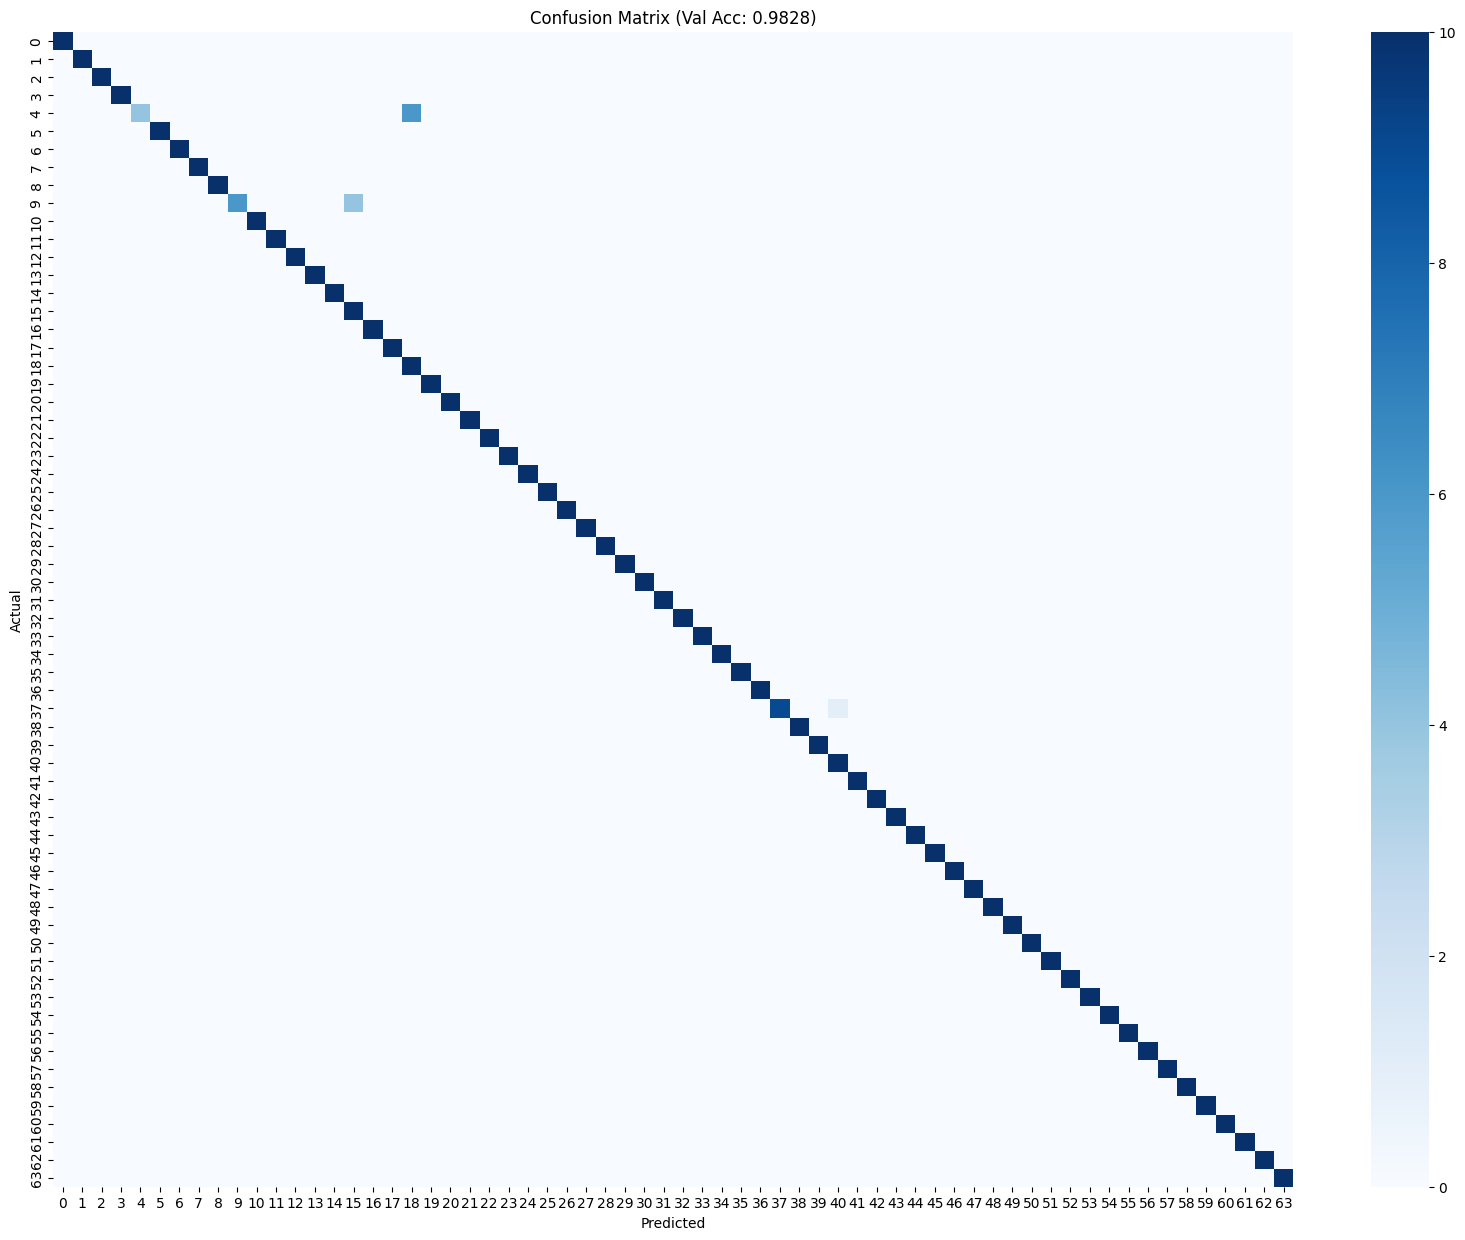


📝 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      0.40      0.57        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        10
           7       1.00      1.00      1.00        10
           8       1.00      1.00      1.00        10
           9       1.00      0.60      0.75        10
          10       1.00      1.00      1.00        10
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00        10
          13       1.00      1.00      1.00        10
          14       1.00      1.00      1.00        10
          15       0.71      1.00      0.83        10
          16       1.00      1.00      1.00        10


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix():
    model.load_state_dict(torch.load("DINOv2_LSA64_Best.pt"))
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for videos, labels in tqdm(val_loader, desc="Evaluating"):
            videos = videos.to(DEVICE)
            B, T, C, H, W = videos.shape
            logits = model(videos.view(B * T, C, H, W)).view(B, T, -1).mean(dim=1)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    # Plotting
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(20, 15))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix (Val Acc: {best_val_acc:.4f})')
    plt.savefig("confusion_matrix.png")
    plt.show()

    print("\n📝 Classification Report:\n")
    print(classification_report(all_labels, all_preds))

plot_confusion_matrix()